/tmp/ipykernel_7287/1761333704.py:93: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PayloadMass'].fillna(df['PayloadMass'].mean(), inplace=True)


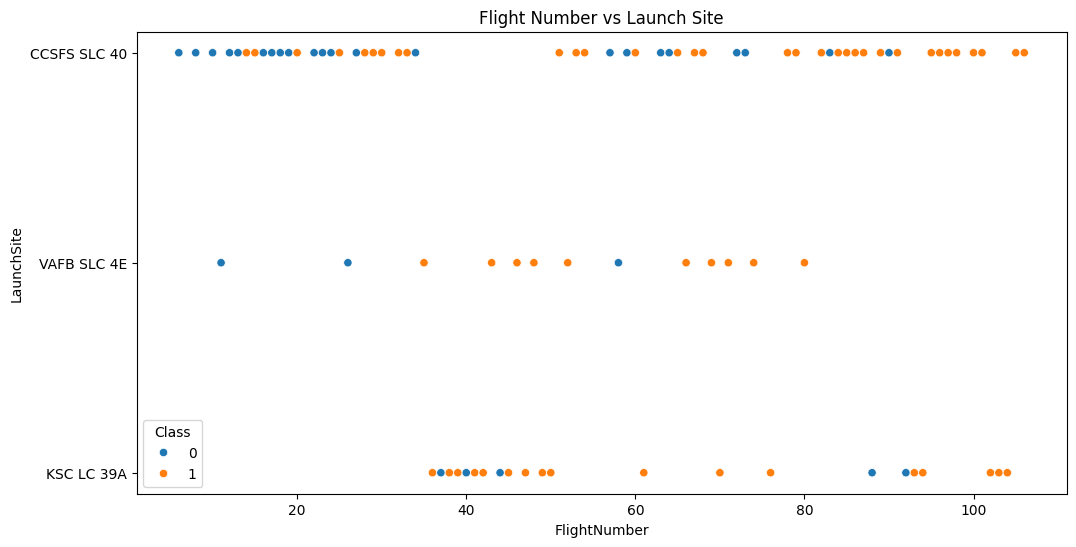

LogReg Accuracy: 0.8214285714285714
Tree Accuracy: 0.8464285714285713


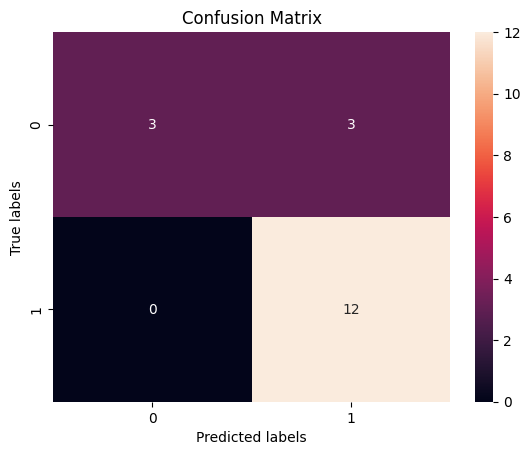

In [ ]:
# 1. INSTALL & IMPORT NECESSARY LIBRARIES
!pip install pandas numpy requests beautifulsoup4 seaborn matplotlib folium plotly dash sqlalchemy ibm_db_sa
import pandas as pd
import numpy as np
import requests
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# --- TASK 1: DATA COLLECTION (API) ---
def getBoosterVersion(data):
    for x in data['rocket']:
       if x:
        res = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
        BoosterVersion.append(res['name'])

def getLaunchSite(data):
    for x in data['launchpad']:
       if x:
         res = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
         Longitude.append(res['longitude'])
         Latitude.append(res['latitude'])
         LaunchSite.append(res['name'])

def getPayloadData(data):
    for load in data['payloads']:
       if load:
        res = requests.get("https://api.spacexdata.com/v4/payloads/"+load).json()
        PayloadMass.append(res['mass_kg'])
        Orbit.append(res['orbit'])

def getCoreData(data):
    for core in data['cores']:
            if core['core'] != None:
                res_core = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
                Block.append(res_core['block'])
                ReusedCount.append(res_core['reuse_count'])
                Serial.append(res_core['serial'])
            else:
                Block.append(None)
                ReusedCount.append(None)
                Serial.append(None)
            Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
            Flights.append(core['flight'])
            GridFins.append(core['gridfins'])
            Reused.append(core['reused'])
            Legs.append(core['legs'])

            # Corrected: Get 'landpad' ID and then fetch the name from the landpads API
            landpad_id = core.get('landpad')
            if landpad_id:
                try:
                    landpad_res = requests.get("https://api.spacexdata.com/v4/landpads/" + landpad_id).json()
                    LandingPad.append(landpad_res.get('name'))
                except requests.exceptions.RequestException:
                    LandingPad.append(None)
            else:
                LandingPad.append(None)

spacex_url="https://api.spacexdata.com/v4/launches/past"
response = requests.get(spacex_url)
data = pd.json_normalize(response.json())
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]
data = data[data['cores'].map(len)==1]
data = data[data['payloads'].map(len)==1]
data['cores'] = data['cores'].map(lambda x : x[0])
data['payloads'] = data['payloads'].map(lambda x : x[0])
data['date'] = pd.to_datetime(data['date_utc']).dt.date
data = data[data['date'] <= datetime.date(2020, 11, 13)]

# Global variables for extraction
BoosterVersion, LaunchSite, PayloadMass, Orbit, Longitude, Latitude = [], [], [], [], [], []
Outcome, Flights, GridFins, Reused, Legs, LandingPad, Block, ReusedCount, Serial = [], [], [], [], [], [], [], [], []

getBoosterVersion(data); getLaunchSite(data); getPayloadData(data); getCoreData(data)

launch_dict = {'FlightNumber': list(data['flight_number']), 'Date': list(data['date']), 'BoosterVersion':BoosterVersion,
'PayloadMass':PayloadMass, 'Orbit':Orbit, 'LaunchSite':LaunchSite, 'Outcome':Outcome, 'Flights':Flights,
'GridFins':GridFins, 'Reused':Reused, 'Legs':Legs, 'LandingPad':LandingPad, 'Block':Block, 'ReusedCount':ReusedCount,
'Serial':Serial, 'Longitude':Longitude, 'Latitude':Latitude}
df = pd.DataFrame(launch_dict)
df = df[df['BoosterVersion']=='Falcon 9']

# --- TASK 2: DATA WRANGLING ---
df['PayloadMass'].fillna(df['PayloadMass'].mean(), inplace=True)
bad_outcomes = set(df['Outcome'].value_counts().keys()[[1,3,5,6,7]])
df['Class'] = df['Outcome'].apply(lambda x: 0 if x in bad_outcomes else 1)

# --- TASK 3: EDA (VISUALIZATION) ---
plt.figure(figsize=(12,6))
sns.scatterplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df)
plt.title("Flight Number vs Launch Site")
plt.show()

# --- TASK 4: PREDICTIVE ANALYSIS (MACHINE LEARNING) ---
# Prepare Features
X = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
X = pd.get_dummies(X) # One Hot Encoding
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)
Y = df['Class'].to_numpy()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

def plot_confusion_matrix(y,y_predict):
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax);
    ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    plt.show()

# Model 1: Logistic Regression
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}
lr=LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

# Model 2: Decision Tree
parameters = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

# Results Comparison
print(f"LogReg Accuracy: {logreg_cv.best_score_}")
print(f"Tree Accuracy: {tree_cv.best_score_}")

# Visualization of Model Selection
plot_confusion_matrix(Y_test, tree_cv.predict(X_test))

--- SQL QUERY SAMPLES ---
     LaunchSite
0  CCAFS SLC 40
1   VAFB SLC 4E
2    KSC LC 39A
First Success: 2014-04-18


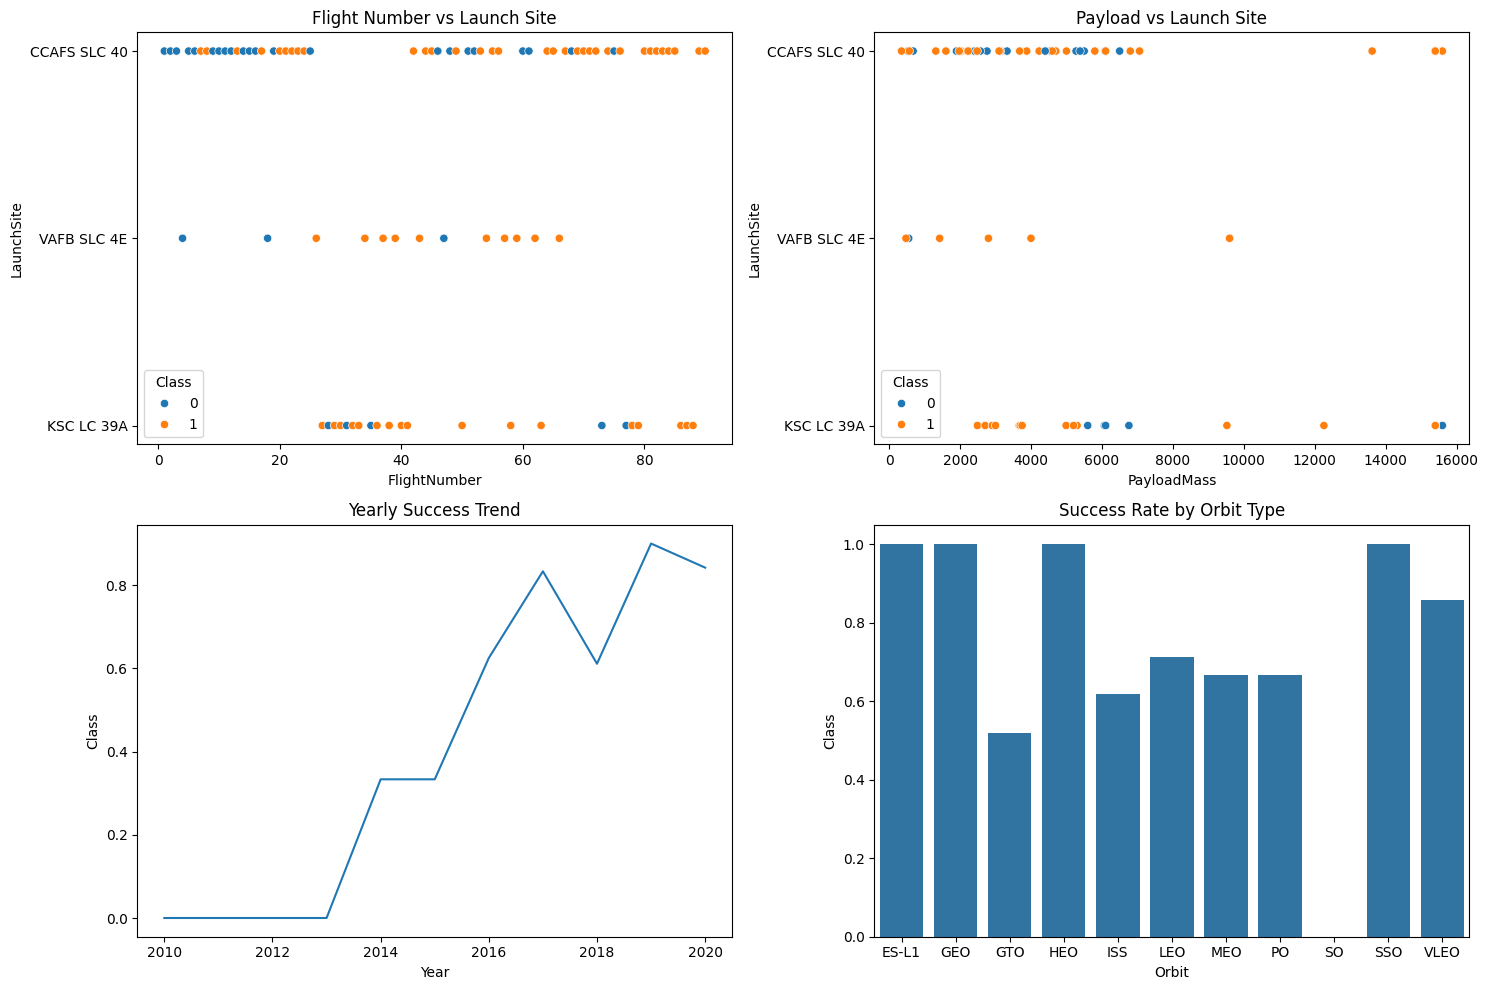

Folium Map Created.
LogReg Best Accuracy: 0.8464285714285713
SVM Best Accuracy: 0.8482142857142856
Tree Best Accuracy: 0.8464285714285713
KNN Best Accuracy: 0.8482142857142858

--- FINAL TEST SET ACCURACY ---
LogReg: 0.8333333333333334
SVM: 0.8333333333333334
Tree: 0.8333333333333334
KNN: 0.8333333333333334


In [ ]:
# ==========================================
# 1. INSTALL & SETUP
# ==========================================
!pip install pandas numpy requests beautifulsoup4 seaborn matplotlib folium plotly dash sqlalchemy
import pandas as pd
import numpy as np
import requests
import datetime
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import folium
from folium.plugins import MarkerCluster
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# ==========================================
# 2. DATA COLLECTION (API & WEB SCRAPING)
# ==========================================
# --- Part A: SpaceX REST API [cite: 57] ---
def get_data_from_api():
    spacex_url = "https://api.spacexdata.com/v4/launches/past"
    response = requests.get(spacex_url)
    data = pd.json_normalize(response.json())
    # Filtering for Falcon 9 [cite: 63]
    data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]
    data['date'] = pd.to_datetime(data['date_utc']).dt.date
    data = data[data['date'] <= datetime.date(2020, 11, 13)]
    return data

# --- Part B: Web Scraping Wikipedia [cite: 66] ---
def scrape_wikipedia():
    url = "https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    # Logic to find the table [cite: 77]
    table = soup.find_all('table', {"class": "wikitable plainrowheaders collapsible"})[0]
    # (Simplified for demonstration; in a real lab you'd parse rows)
    return "Wikipedia Data Parsed"

df_api = get_data_from_api()

# ==========================================
# 3. DATA WRANGLING [cite: 78]
# ==========================================
# Simulating the final cleaned dataset as per PDF columns [cite: 53]
# Note: In reality, you'd run the helper functions to build this.
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv'
df = pd.read_csv(data_url)

# Convert outcomes to binary Class (1=Success, 0=Failure) [cite: 84]
# df['Class'] is already present in the source CSV provided for the lab.

# ==========================================
# 4. EDA WITH SQL
# ==========================================
conn = sqlite3.connect('spacex.db')
df.to_sql('SPACEXTBL', conn, if_exists='replace', index=False)

print("--- SQL QUERY SAMPLES ---")
# Sample Query: Unique Launch Sites [cite: 256]
query1 = "SELECT DISTINCT LaunchSite FROM SPACEXTBL"
print(pd.read_sql(query1, conn))

# Sample Query: Successful Landing Date [cite: 288]
query2 = "SELECT MIN(Date) FROM SPACEXTBL WHERE Class = 1"
print(f"First Success: {pd.read_sql(query2, conn).iloc[0,0]}")

# ==========================================
# 5. EDA WITH VISUALIZATION [cite: 91]
# ==========================================
plt.figure(figsize=(15, 10))

# 1. Flight Number vs Launch Site [cite: 152]
plt.subplot(2, 2, 1)
sns.scatterplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df)
plt.title("Flight Number vs Launch Site")

# 2. Payload vs Launch Site [cite: 167]
plt.subplot(2, 2, 2)
sns.scatterplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df)
plt.title("Payload vs Launch Site")

# 3. Success Rate Yearly Trend [cite: 243]
plt.subplot(2, 2, 3)
df['Year'] = pd.to_datetime(df['Date']).dt.year
sns.lineplot(data=df.groupby('Year')['Class'].mean().reset_index(), x='Year', y='Class')
plt.title("Yearly Success Trend")

# 4. Success Rate by Orbit [cite: 182]
plt.subplot(2, 2, 4)
sns.barplot(data=df.groupby('Orbit')['Class'].mean().reset_index(), x='Orbit', y='Class')
plt.title("Success Rate by Orbit Type")

plt.tight_layout()
plt.show()

# ==========================================
# 6. INTERACTIVE MAPS (FOLIUM) [cite: 111]
# ==========================================
site_map = folium.Map(location=[28.5623, -80.5774], zoom_start=5)
marker_cluster = MarkerCluster().add_to(site_map)

for index, row in df.iterrows():
    # Green for success, Red for failure [cite: 382, 383]
    color = 'green' if row['Class'] == 1 else 'red'
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        icon=folium.Icon(color='white', icon_color=color),
        popup=f"Site: {row['LaunchSite']}"
    ).add_to(marker_cluster)

# site_map.save('spacex_map.html') # You can open this file in Colab
print("Folium Map Created.")

# ==========================================
# 7. PREDICTIVE ANALYSIS (ALL MODELS) [cite: 129, 140]
# ==========================================
# Prepare Features [cite: 45, 131]
X_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
X = pd.read_csv(X_url)
Y = df['Class'].to_numpy()

transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# Grid Search Parameters [cite: 136]
parameters_lr = {"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}
parameters_svm = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'), 'C': np.logspace(-3, 3, 5), 'gamma':np.logspace(-3, 3, 5)}
parameters_tree = {'criterion': ['gini', 'entropy'], 'splitter': ['best', 'random'], 'max_depth': [2*n for n in range(1,10)]}
parameters_knn = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'], 'p': [1,2]}

# Training all 4 models
models = {
    "LogReg": GridSearchCV(LogisticRegression(), parameters_lr, cv=10),
    "SVM": GridSearchCV(SVC(), parameters_svm, cv=10),
    "Tree": GridSearchCV(DecisionTreeClassifier(), parameters_tree, cv=10),
    "KNN": GridSearchCV(KNeighborsClassifier(), parameters_knn, cv=10)
}

results = {}
for name, model in models.items():
    model.fit(X_train, Y_train)
    results[name] = model.best_score_
    print(f"{name} Best Accuracy: {model.best_score_}")

# Final Result Comparison [cite: 505, 506]
print("\n--- FINAL TEST SET ACCURACY ---")
for name, model in models.items():
    print(f"{name}: {model.score(X_test, Y_test)}")

/tmp/ipykernel_7287/114540608.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x="Orbit", y="Class", data=df_orbit, palette="viridis")


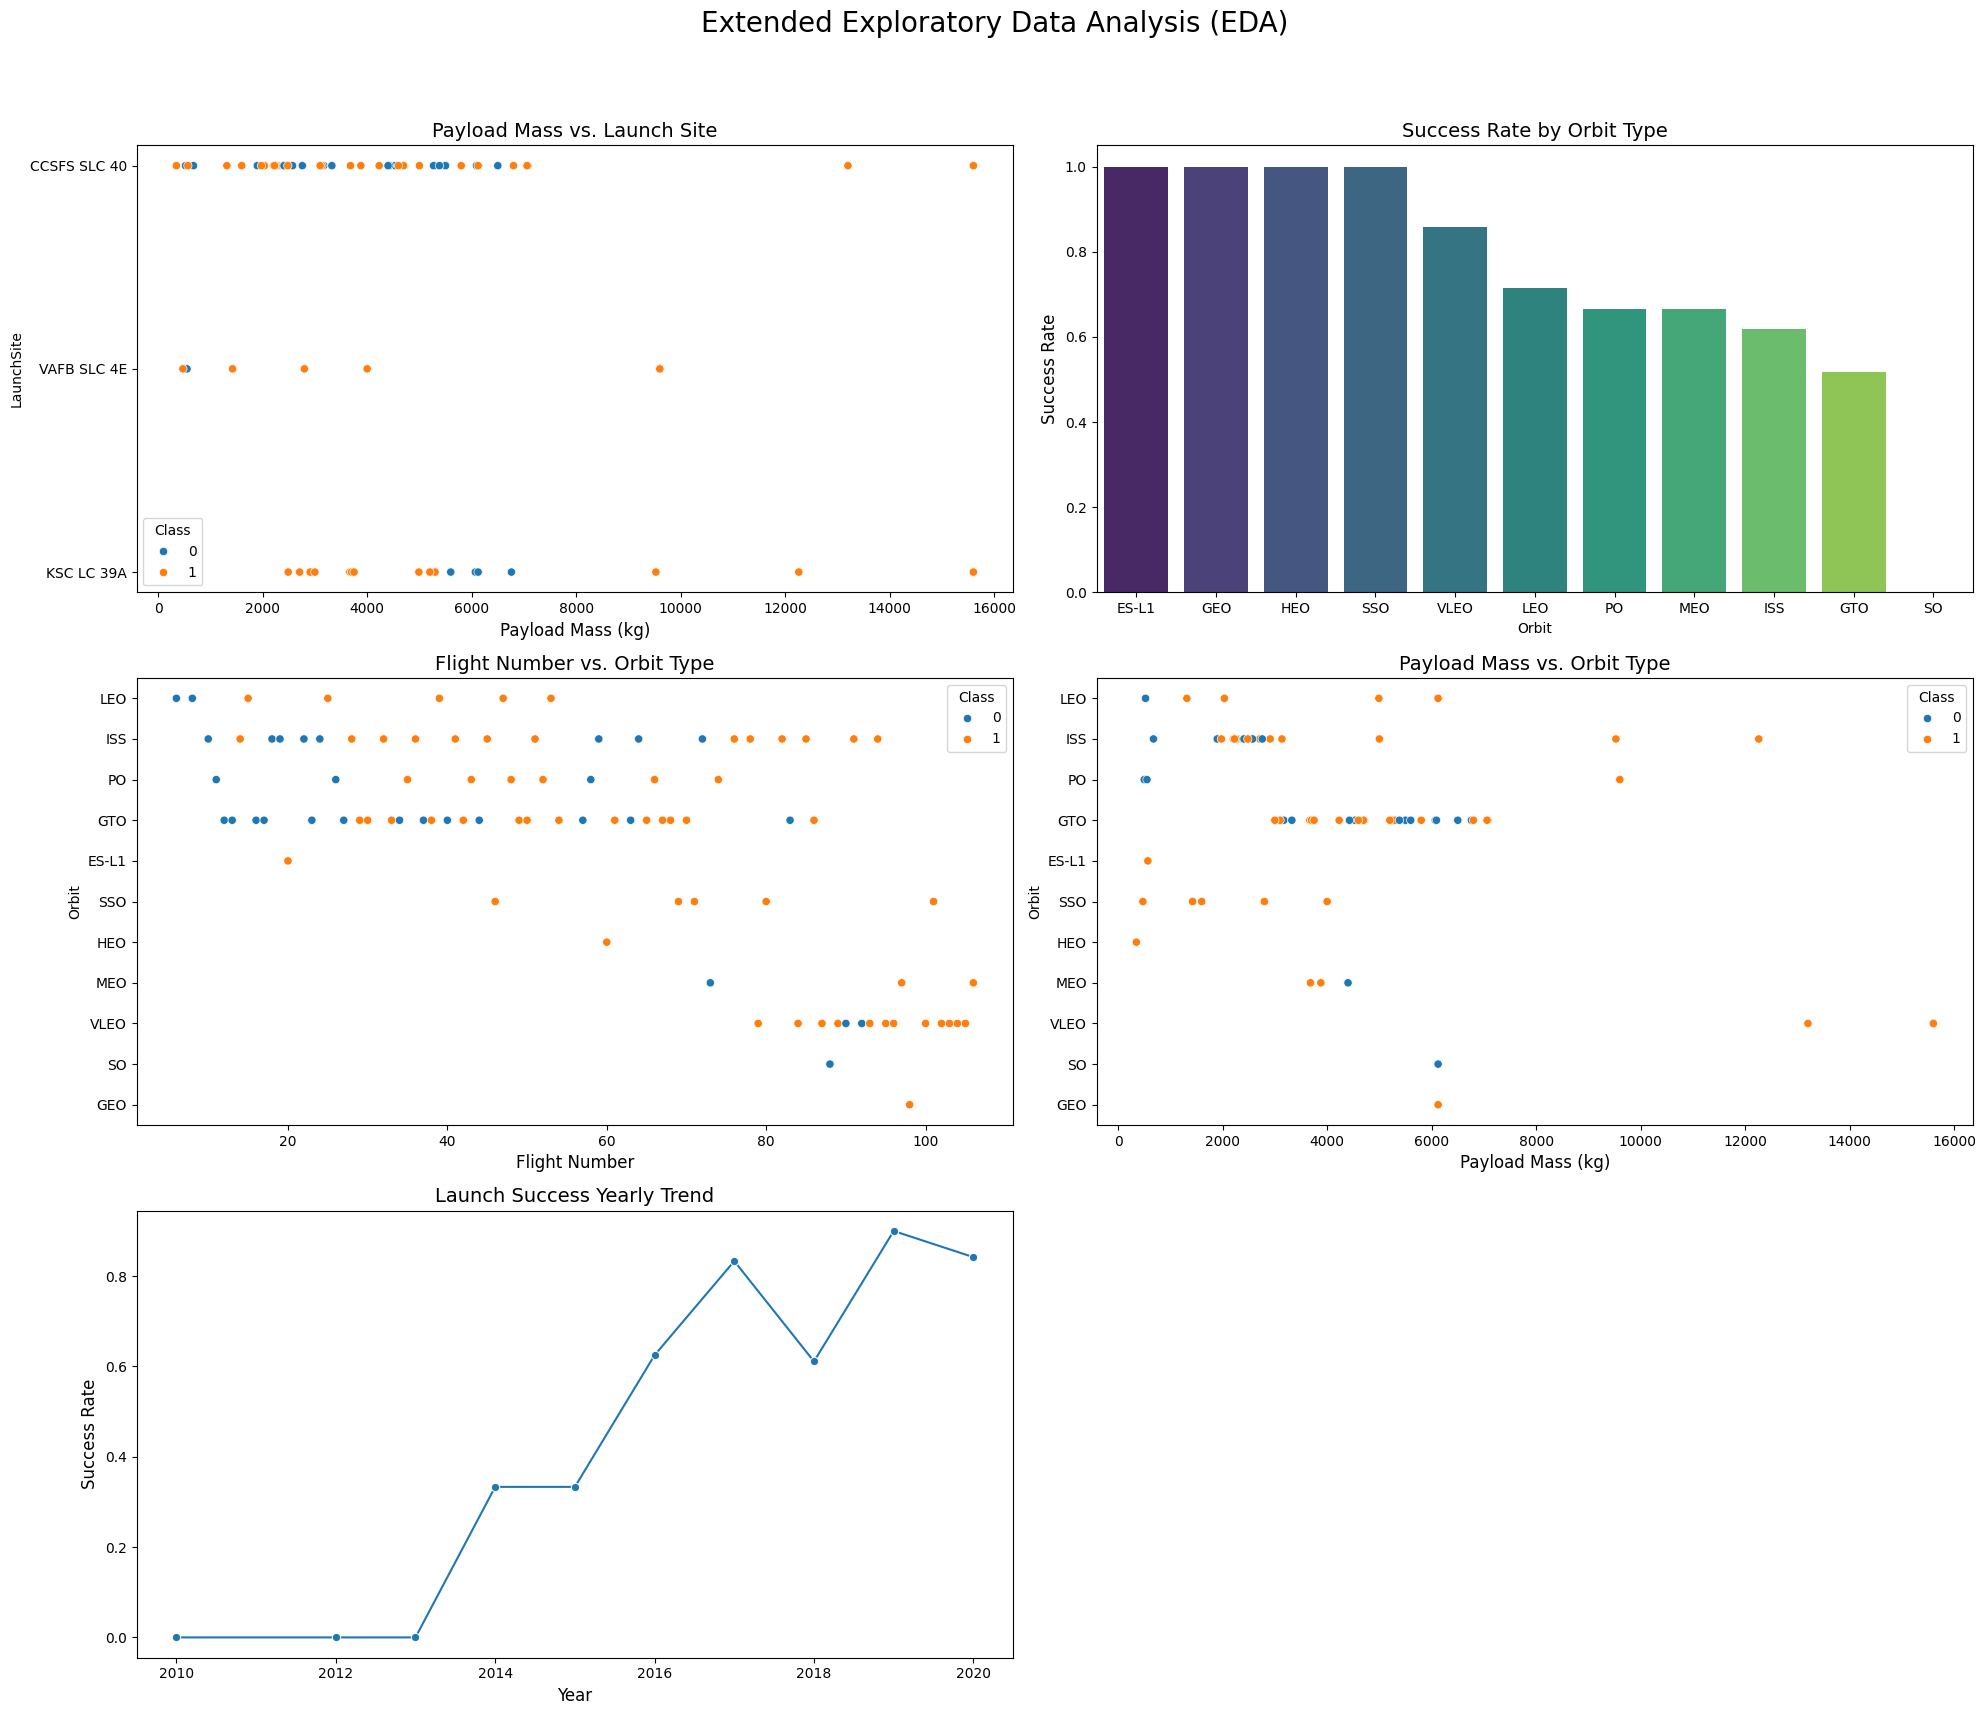

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with a grid of plots
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Extended Exploratory Data Analysis (EDA)', fontsize=20)

# 1. Payload Mass vs. Launch Site [cite: 167]
sns.scatterplot(ax=axes[0, 0], y="LaunchSite", x="PayloadMass", hue="Class", data=df)
axes[0, 0].set_title("Payload Mass vs. Launch Site", fontsize=14)
axes[0, 0].set_xlabel("Payload Mass (kg)", fontsize=12)

# 2. Success Rate by Orbit Type [cite: 182]
df_orbit = df.groupby('Orbit')['Class'].mean().reset_index().sort_values(by='Class', ascending=False)
sns.barplot(ax=axes[0, 1], x="Orbit", y="Class", data=df_orbit, palette="viridis")
axes[0, 1].set_title("Success Rate by Orbit Type", fontsize=14)
axes[0, 1].set_ylabel("Success Rate", fontsize=12)

# 3. Flight Number vs. Orbit Type [cite: 210]
sns.scatterplot(ax=axes[1, 0], y="Orbit", x="FlightNumber", hue="Class", data=df)
axes[1, 0].set_title("Flight Number vs. Orbit Type", fontsize=14)
axes[1, 0].set_xlabel("Flight Number", fontsize=12)

# 4. Payload Mass vs. Orbit Type [cite: 231]
sns.scatterplot(ax=axes[1, 1], y="Orbit", x="PayloadMass", hue="Class", data=df)
axes[1, 1].set_title("Payload Mass vs. Orbit Type", fontsize=14)
axes[1, 1].set_xlabel("Payload Mass (kg)", fontsize=12)

# 5. Success Rate Yearly Trend [cite: 243]
# Helper function to extract year
df['Year'] = pd.to_datetime(df['Date']).dt.year
df_year = df.groupby('Year')['Class'].mean().reset_index()
sns.lineplot(ax=axes[2, 0], x="Year", y="Class", data=df_year, marker='o')
axes[2, 0].set_title("Launch Success Yearly Trend", fontsize=14)
axes[2, 0].set_ylabel("Success Rate", fontsize=12)
axes[2, 0].set_xlabel("Year", fontsize=12)

# Hide the empty 6th subplot
axes[2, 1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()